In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Set Datalist

In [2]:
file_path = r'C:\Users\sharif\Desktop\Final5.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""METHANOL"").F","STREAMS(""METHANOL"").T","STREAMS(""METHANOL"").P","STREAMS(""FV"").F","STREAMS(""FV"").T","STREAMS(""FV"").P","STREAMS(""FV"").Zmn(""1-BUT-01"")","STREAMS(""FV"").Zmn(""ISOBU-01"")","STREAMS(""P1"").F","STREAMS(""P1"").T",...,"BLOCKS(""RDCOLUMN"").Stage(4).T","BLOCKS(""RDCOLUMN"").Stage(5).T","BLOCKS(""RDCOLUMN"").Stage(6).T","BLOCKS(""RDCOLUMN"").Stage(7).T","BLOCKS(""RDCOLUMN"").Stage(8).T","BLOCKS(""RDCOLUMN"").Stage(9).T","BLOCKS(""RDCOLUMN"").Stage(10).T","BLOCKS(""RDCOLUMN"").Stage(11).T","STREAMS(""P1"").Zmn(""1-BUT-01"")","STREAMS(""P2"").Zmn(""METHY-01"")"
0,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
1,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
2,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
3,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
4,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3313,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974


In [3]:
df.describe

<bound method NDFrame.describe of        STREAMS("METHANOL").F  STREAMS("METHANOL").T  STREAMS("METHANOL").P  \
0                    712.082                  46.85                1.01325   
1                    712.082                  46.85                1.01325   
2                    712.082                  46.85                1.01325   
3                    712.082                  46.85                1.01325   
4                    712.082                  46.85                1.01325   
...                      ...                    ...                    ...   
12648                718.993                  46.85                1.01325   
12649                718.993                  46.85                1.01325   
12650                718.993                  46.85                1.01325   
12651                718.993                  46.85                1.01325   
12652                718.993                  46.85                1.01325   

       STREAMS("FV").F  STREA

# PreProcessing

In [4]:
x = df.drop(['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")'] , axis=1).values
y = df[['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")']].values

In [5]:
x.shape , y.shape

((12653, 36), (12653, 2))

In [6]:
x

array([[712.082  ,  46.85   ,   1.01325, ..., 123.67   , 123.896  ,
        128.634  ],
       [712.082  ,  46.85   ,   1.01325, ..., 123.67   , 123.896  ,
        128.634  ],
       [712.082  ,  46.85   ,   1.01325, ..., 123.67   , 123.896  ,
        128.634  ],
       ...,
       [718.993  ,  46.85   ,   1.01325, ..., 106.044  , 104.518  ,
        107.674  ],
       [718.993  ,  46.85   ,   1.01325, ..., 106.044  , 104.518  ,
        107.674  ],
       [718.993  ,  46.85   ,   1.01325, ..., 106.044  , 104.518  ,
        107.674  ]], shape=(12653, 36))

In [7]:
from sklearn.model_selection import train_test_split

x_train , x_temp , y_train , y_temp = train_test_split(x,y,test_size=0.4 , random_state=7)

In [8]:
x_test , x_val , y_test , y_val = train_test_split(x_temp,y_temp,test_size=0.375 , random_state=7)

In [9]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape, x_val.shape , y_val.shape

((7591, 36), (3163, 36), (7591, 2), (3163, 2), (1899, 36), (1899, 2))

In [10]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()
x_train = Scaler.fit_transform(x_train)
x_test = Scaler.transform(x_test)
x_val = Scaler.transform(x_val)

In [11]:
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)
x_val = x_val.reshape(x_val.shape[0], x_val.shape[1], 1)

# Model Definition

In [12]:
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPool1D, LeakyReLU, Input

model = tf.keras.Sequential()
model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))

model.add(Conv1D(filters=64, kernel_size=3, name="Conv1D_1"))
model.add(LeakyReLU(alpha=0.2))
model.add(MaxPool1D(pool_size=2, name="MaxPool1D_1"))
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add (Dense(2 , activation = 'sigmoid'))

model.compile(optimizer = 'adam' , loss = 'mse' , metrics = ['mae'])
model.summary()

d:\ArshadProjectVSCode\final\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1D_1 (Conv1D)               │ (None, 34, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 34, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1D_1 (MaxPooling1D)      │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1088)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       139,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,034 (578.26 KB)

 Trainable params: 148,034 (578.26 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=350, restore_best_weights=True)

In [14]:
hist_1 = model.fit(x_train , y_train , epochs = 1000 , batch_size =40 , validation_data = (x_val , y_val) , callbacks=[early_stop])

Epoch 1/1000
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0262 - mae: 0.0992 - val_loss: 0.0042 - val_mae: 0.0296
Epoch 2/1000
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0049 - mae: 0.0341 - val_loss: 0.0039 - val_mae: 0.0229
Epoch 3/1000
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0043 - mae: 0.0291 - val_loss: 0.0037 - val_mae: 0.0179
Epoch 4/1000
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0035 - mae: 0.0256 - val_loss: 2.1276e-04 - val_mae: 0.0088
Epoch 5/1000
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2013e-04 - mae: 0.0188 - val_loss: 1.7465e-04 - val_mae: 0.0086
Epoch 6/1000
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.2319e-04 - mae: 0.0167 - val_loss: 1.8520e-04 - val_mae: 0.0117
Epoch 7/1000
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.2548e-04 - mae: 0.0156 - val_loss: 9.4985e-05 - val_mae: 0.0072
Epoch 8/1000
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.0790e-04 - mae: 0.0152 - val_loss: 9.0895e-05 - val_mae: 0.0068
Epoc

# Test Data Test

In [15]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6575e-06 - mae: 0.0010  
Test Loss: 3.8910166040295735e-06
Test MAE: 0.001011780695989728


In [16]:
y_pred = model.predict(x_test)

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [17]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

mse = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:{mse}")
print(f"MAE:{mae}")
print(f"R2 Score:{r2}")

MSE:3.89101482223622e-06
MAE:0.0010117794573675694
R2 Score:0.9898836236974113


In [18]:
results = pd.DataFrame({
    'Actual MoleFractionTX': y_test[:, 0],
    'Predicted MoleFractionTX': y_pred[:, 0],
    'Actual MoleFractionHX': y_test[:, 1],
    'Predicted MoleFractionHX': y_pred[:, 1]
})

results.head()

,Actual MoleFractionTX,Predicted MoleFractionTX,Actual MoleFractionHX,Predicted MoleFractionHX
0,0.965967,0.965306,0.936027,0.936387
1,0.957550,0.957589,0.937382,0.936958
2,0.967416,0.966065,0.938536,0.936644
3,0.958695,0.958507,0.939423,0.938447
4,0.571413,0.567600,0.937448,0.937586


Total number of samples: 3163
Plotting first 5000 samples.


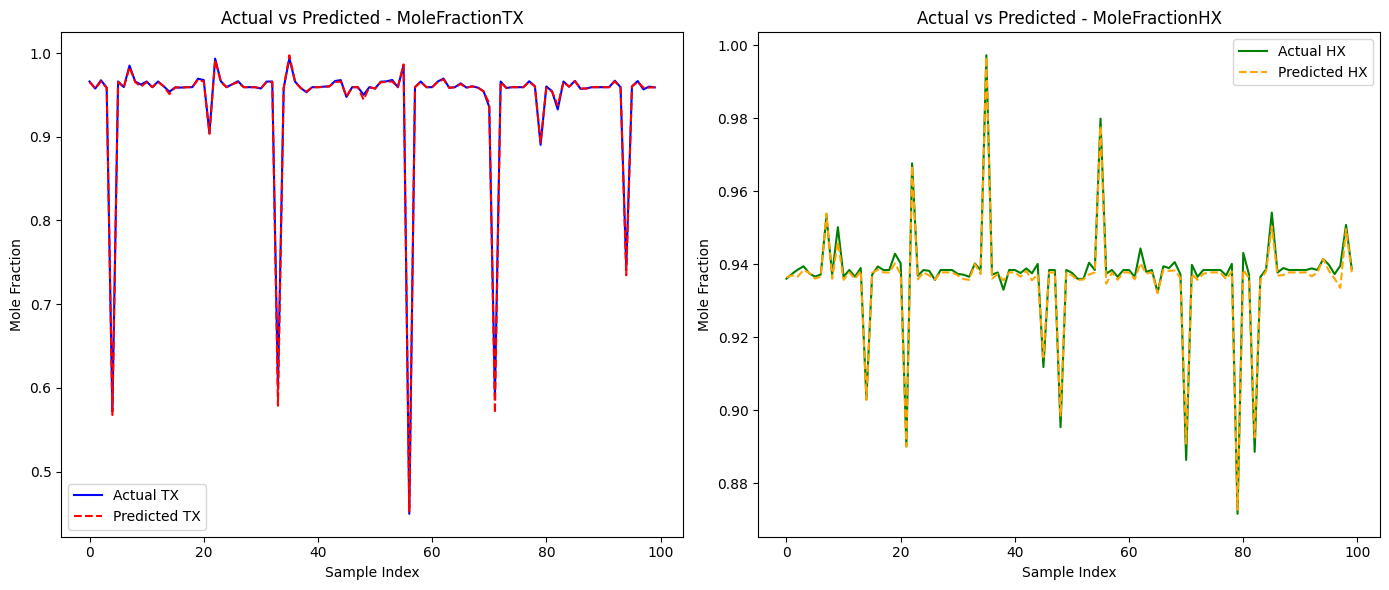

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# بررسی تعداد کل داده‌ها
num_samples = len(results)
print(f"Total number of samples: {num_samples}")

# اگر داده‌ها بیشتر از 5000 بودند، فقط 5000 تای اول را انتخاب کن
if num_samples >= 100:
    subset = results.iloc[:100]
    print("Plotting first 5000 samples.")
else:
    subset = results
    print("Plotting all available samples.")

# رسم نمودار
plt.figure(figsize=(14, 6))

# MoleFractionTX
plt.subplot(1, 2, 1)
plt.plot(subset['Actual MoleFractionTX'].values, label='Actual TX', color='blue')
plt.plot(subset['Predicted MoleFractionTX'].values, label='Predicted TX', color='red', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionTX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

# MoleFractionHX
plt.subplot(1, 2, 2)
plt.plot(subset['Actual MoleFractionHX'].values, label='Actual HX', color='green')
plt.plot(subset['Predicted MoleFractionHX'].values, label='Predicted HX', color='orange', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionHX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [21]:
tolerances = [0.005, 0.002, 0.001]

# دو خروجی داریم: TX (ستون 0) و HX (ستون 1)
tx_true = y_test[:, 0]
tx_pred = y_pred[:, 0]
hx_true = y_test[:, 1]
hx_pred = y_pred[:, 1]

tx_results = []
hx_results = []

In [22]:
for tol in tolerances:
    tx_acc = percentage_within_tolerance(tx_true, tx_pred, tolerance=tol)
    hx_acc = percentage_within_tolerance(hx_true, hx_pred, tolerance=tol)
    tx_results.append(tx_acc)
    hx_results.append(hx_acc)
    print(f"TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {tx_acc:.2f}%")
    print(f"HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {hx_acc:.2f}%")
    print('-'*50)

TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 97.82%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 97.91%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 90.77%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 87.42%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 78.56%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 70.60%
--------------------------------------------------


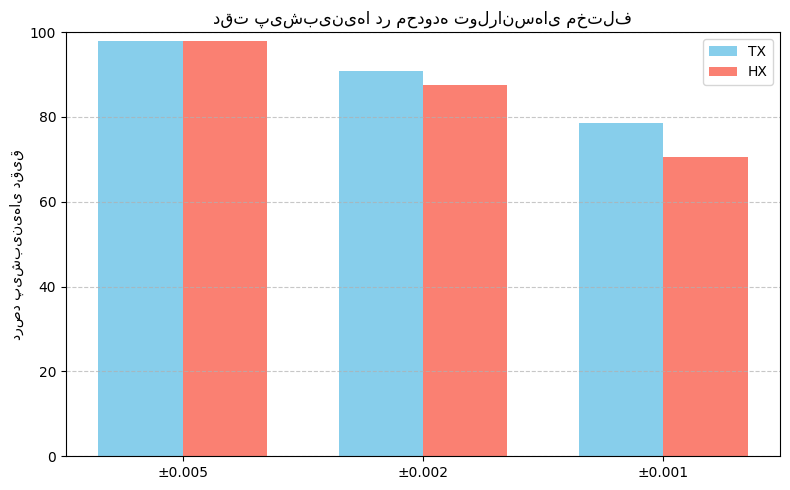

In [23]:
x_labels = [f"±{tol}" for tol in tolerances]
x = np.arange(len(tolerances))

plt.figure(figsize=(8, 5))
bar_width = 0.35

plt.bar(x - bar_width/2, tx_results, width=bar_width, label='TX', color='skyblue')
plt.bar(x + bar_width/2, hx_results, width=bar_width, label='HX', color='salmon')

plt.xticks(x, x_labels)
plt.ylim(0, 100)
plt.ylabel("درصد پیش‌بینی‌های دقیق")
plt.title("دقت پیش‌بینی‌ها در محدوده تولرانس‌های مختلف")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

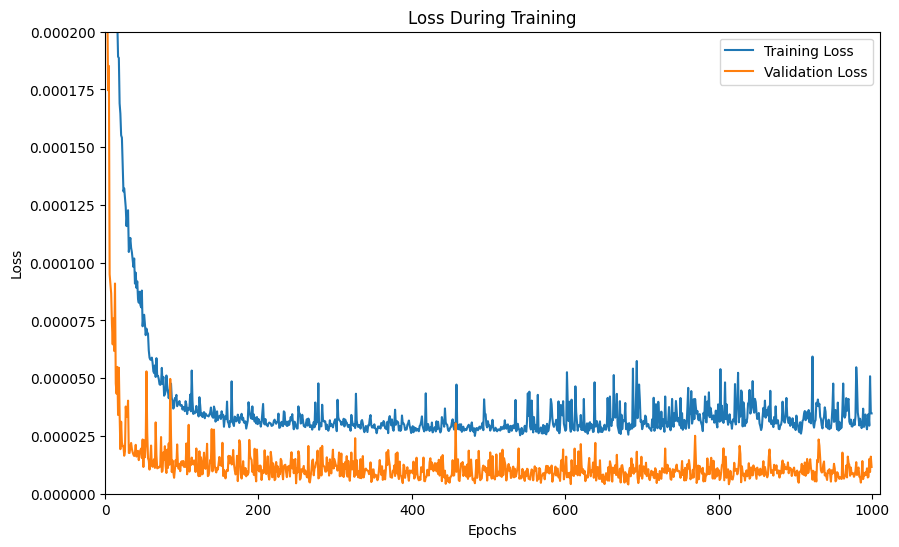

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(hist_1.history['loss'], label='Training Loss')
plt.plot(hist_1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.xlim(0,1010)
plt.ylim(0,0.0002)
plt.show()

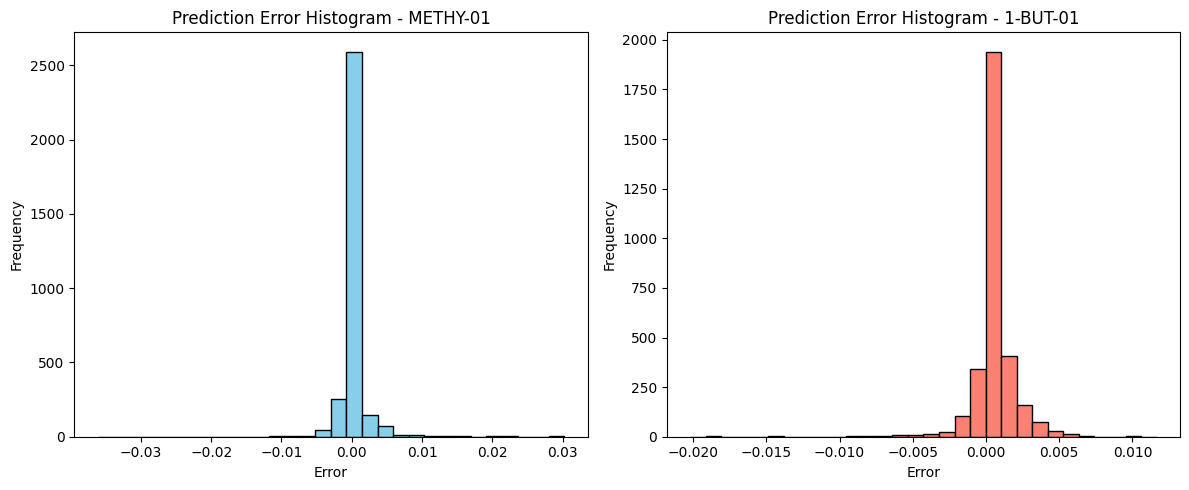

In [25]:
errors_tx = y_test[:, 0] - y_pred[:, 0]
errors_hx = y_test[:, 1] - y_pred[:, 1]

plt.figure(figsize=(12, 5))

# Histogram for METHY-01
plt.subplot(1, 2, 1)
plt.hist(errors_tx, bins=30, color='skyblue', edgecolor='black')
plt.title('Prediction Error Histogram - METHY-01')
plt.xlabel('Error')
plt.ylabel('Frequency')

# Histogram for 1-BUT-01
plt.subplot(1, 2, 2)
plt.hist(errors_hx, bins=30, color='salmon', edgecolor='black')
plt.title('Prediction Error Histogram - 1-BUT-01')
plt.xlabel('Error')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()